In [1]:
# Imports

import os
import numpy as np
import matplotlib.pyplot as plt

from PIL import Image

from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D, UpSampling2D
from tensorflow.keras.models import Model
from tensorflow.keras.optimizers import Adam

## Task 1: Dataset Preparation and Noise Addition

In [2]:
from google.colab import drive
import os

drive.mount("/content/drive")

base_path = "/content/drive/MyDrive/AI and ML/DevanagariHandwrittenDigitDataset"

print("Dataset exists:", os.path.exists(base_path))

print("\nTop-level items:")
for item in os.listdir(base_path):
    print("-", item)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Dataset exists: True

Top-level items:
- Train
- Test


Check dataset structure

In [3]:
# Task 1B - Check folders

import os

base_path = "/content/drive/MyDrive/AI and ML/DevanagariHandwrittenDigitDataset"

train_dir = base_path + "/Train"
test_dir = base_path + "/Test"

print("Train exists:", os.path.exists(train_dir))
print("Test exists:", os.path.exists(test_dir))

print("\nClasses in Train:")
classes = sorted(os.listdir(train_dir))
print(classes)

print("\nTotal classes:", len(classes))

Train exists: True
Test exists: True

Classes in Train:
['digit_0', 'digit_1', 'digit_2', 'digit_3', 'digit_4', 'digit_5', 'digit_6', 'digit_7', 'digit_8', 'digit_9']

Total classes: 10


Load images using PIL

In [4]:
# Task 1C - Load sample images

import os
import numpy as np
from PIL import Image

img_size = 28
max_per_class = 500   # use small number first

X = []
y = []

for label, cls in enumerate(classes):
    folder = train_dir + "/" + cls
    files = os.listdir(folder)[:max_per_class]

    for file in files:
        img_path = folder + "/" + file

        try:
            img = Image.open(img_path).convert("L")
            img = img.resize((img_size, img_size))
            X.append(np.array(img))
            y.append(label)
        except:
            pass

X = np.array(X)
y = np.array(y)

print("Images shape:", X.shape)
print("Labels shape:", y.shape)
print("Pixel range:", X.min(), "to", X.max())

Images shape: (5000, 28, 28)
Labels shape: (5000,)
Pixel range: 0 to 255


Normalize and reshape images

In [5]:
# Task 1D - Normalize and reshape

X = X.astype("float32") / 255.0
X = X.reshape(-1, 28, 28, 1)

print("Images shape:", X.shape)
print("Pixel range:", X.min(), "to", X.max())

Images shape: (5000, 28, 28, 1)
Pixel range: 0.0 to 1.0


Split dataset

In [6]:
# Task 1E - Train validation split

from sklearn.model_selection import train_test_split

x_train, x_val = train_test_split(
    X,
    test_size=0.2,
    random_state=42,
    shuffle=True
)

print("Training images:", x_train.shape)
print("Validation images:", x_val.shape)

Training images: (4000, 28, 28, 1)
Validation images: (1000, 28, 28, 1)


Add Gaussian noise

In [7]:
# Task 1F - Add noise

import numpy as np

noise_factor = 0.5

x_train_noisy = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_val_noisy = x_val + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_val.shape
)

x_train_noisy = np.clip(x_train_noisy, 0.0, 1.0)
x_val_noisy = np.clip(x_val_noisy, 0.0, 1.0)

print("Clean train range:", x_train.min(), "to", x_train.max())
print("Noisy train range:", x_train_noisy.min(), "to", x_train_noisy.max())
print("Noisy train shape:", x_train_noisy.shape)
print("Noisy val shape:", x_val_noisy.shape)

Clean train range: 0.0 to 1.0
Noisy train range: 0.0 to 1.0
Noisy train shape: (4000, 28, 28, 1)
Noisy val shape: (1000, 28, 28, 1)


Show clean and noisy images

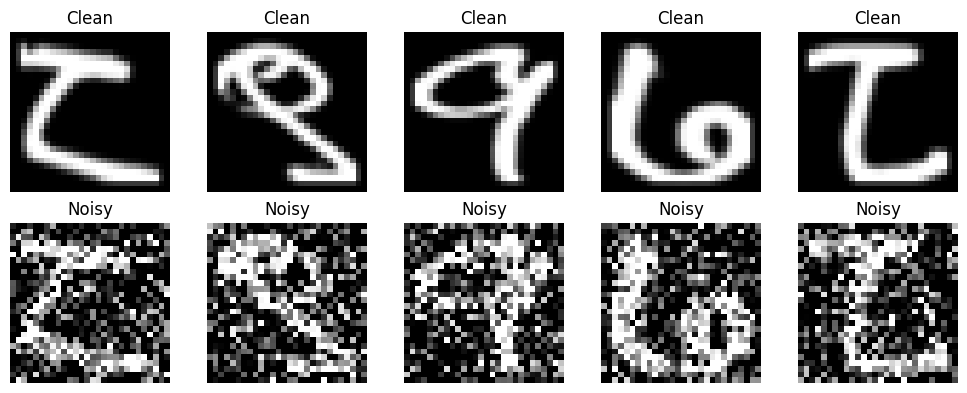

In [8]:
# Task 1G - Visualize noise

import matplotlib.pyplot as plt

n = 5

plt.figure(figsize=(10, 4))

for i in range(n):
    # clean image
    plt.subplot(2, n, i + 1)
    plt.imshow(x_train[i].reshape(28, 28), cmap="gray")
    plt.title("Clean")
    plt.axis("off")

    # noisy image
    plt.subplot(2, n, i + 1 + n)
    plt.imshow(x_train_noisy[i].reshape(28, 28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Task 2: Build the denoising convolutional autoencoder.

Build encoder and decoder

In [9]:
# Task 2B - Build autoencoder

input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
x = MaxPooling2D((2, 2), padding="same")(x)

x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
encoded = MaxPooling2D((2, 2), padding="same")(x)

# Decoder
x = Conv2D(64, (3, 3), activation="relu", padding="same")(encoded)
x = UpSampling2D((2, 2))(x)

x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = UpSampling2D((2, 2))(x)

decoded = Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

autoencoder = Model(input_img, decoded)

Compile and check model summary

In [10]:
# Task 2C - Compile model

autoencoder.compile(
    optimizer=Adam(),
    loss="binary_crossentropy"
)

autoencoder.summary()

Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 32)     │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 7, 7, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d (UpSampling2D)    │ (None, 14, 14, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 14, 14, 32)     │        18,464 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ up_sampling2d_1 (UpSampling2D)  │ (None, 28, 28, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 28, 28, 1)      │           289 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 74,497 (291.00 KB)

 Trainable params: 74,497 (291.00 KB)

 Non-trainable params: 0 (0.00 B)

## Task 3A - Train the autoencoder

In [11]:
# Task 3A - Train autoencoder

history = autoencoder.fit(
    x_train_noisy, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_val_noisy, x_val)
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 370ms/step - loss: 0.5258 - val_loss: 0.3472
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 438ms/step - loss: 0.2873 - val_loss: 0.2551
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 14s 457ms/step - loss: 0.2405 - val_loss: 0.2329
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 438ms/step - loss: 0.2228 - val_loss: 0.2182
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 18s 366ms/step - loss: 0.2148 - val_loss: 0.2130
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 408ms/step - loss: 0.2095 - val_loss: 0.2112
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 364ms/step - loss: 0.2066 - val_loss: 0.2061
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 363ms/step - loss: 0.2041 - val_loss: 0.2050
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 407ms/step - loss: 0.2023 - val_loss: 0.2037
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 408ms/step - loss: 0.2001 - val_loss: 0.2006


Plot loss curve

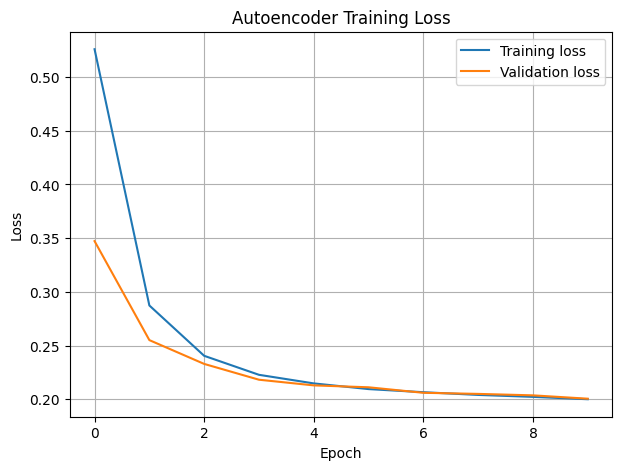

In [12]:
# Task 3B - Plot loss

plt.figure(figsize=(7, 5))

plt.plot(history.history["loss"], label="Training loss")
plt.plot(history.history["val_loss"], label="Validation loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Autoencoder Training Loss")
plt.legend()
plt.grid(True)
plt.show()

## Task 4: Evaluate the autoencoder and show noisy vs denoised vs clean images.

Predict denoised images

In [13]:
# Task 4A - Predict denoised images

denoised_images = autoencoder.predict(x_val_noisy)

print("Noisy images shape:", x_val_noisy.shape)
print("Denoised images shape:", denoised_images.shape)
print("Clean images shape:", x_val.shape)

print("Denoised pixel range:", denoised_images.min(), "to", denoised_images.max())

32/32 ━━━━━━━━━━━━━━━━━━━━ 2s 47ms/step
Noisy images shape: (1000, 28, 28, 1)
Denoised images shape: (1000, 28, 28, 1)
Clean images shape: (1000, 28, 28, 1)
Denoised pixel range: 2.1872518e-08 to 0.99470574


Visualize noisy, denoised, and clean images

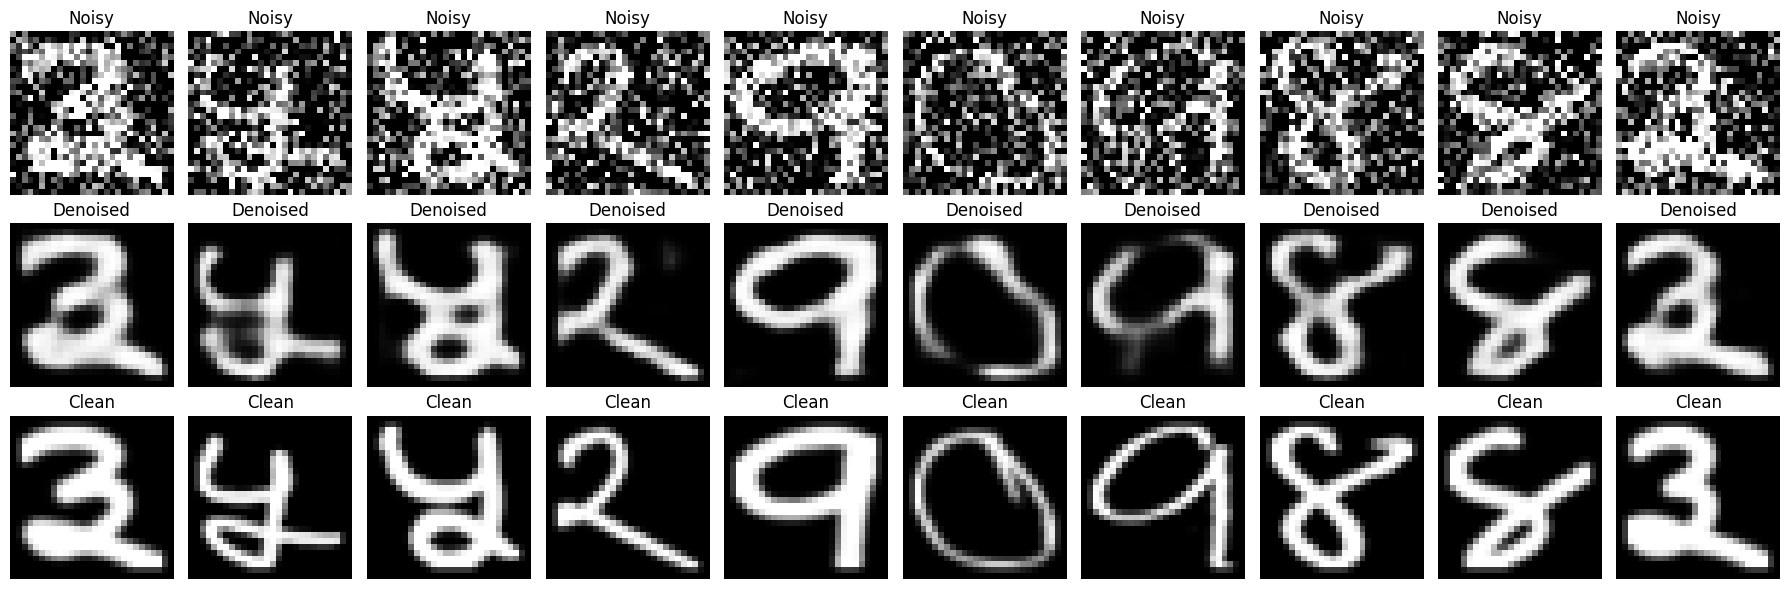

In [14]:
# Task 4B - Show results

n = 10

plt.figure(figsize=(18, 6))

for i in range(n):
    # noisy image
    plt.subplot(3, n, i + 1)
    plt.imshow(x_val_noisy[i].reshape(28, 28), cmap="gray")
    plt.title("Noisy")
    plt.axis("off")

    # denoised image
    plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_images[i].reshape(28, 28), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

    # clean image
    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_val[i].reshape(28, 28), cmap="gray")
    plt.title("Clean")
    plt.axis("off")

plt.tight_layout()
plt.show()

Task 5: Experiment and write observations is left.

Experiment with lower noise

In [15]:
# Task 5A - Try lower noise level

noise_factor = 0.3

x_train_noisy_03 = x_train + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_train.shape
)

x_val_noisy_03 = x_val + noise_factor * np.random.normal(
    loc=0.0,
    scale=1.0,
    size=x_val.shape
)

x_train_noisy_03 = np.clip(x_train_noisy_03, 0.0, 1.0)
x_val_noisy_03 = np.clip(x_val_noisy_03, 0.0, 1.0)

print("Lower noise train shape:", x_train_noisy_03.shape)
print("Lower noise val shape:", x_val_noisy_03.shape)
print("Pixel range:", x_train_noisy_03.min(), "to", x_train_noisy_03.max())

Lower noise train shape: (4000, 28, 28, 1)
Lower noise val shape: (1000, 28, 28, 1)
Pixel range: 0.0 to 1.0


Train model with lower noise

In [16]:
# Task 5B - Train with lower noise

input_img = Input(shape=(28, 28, 1))

# Encoder
x = Conv2D(32, (3, 3), activation="relu", padding="same")(input_img)
x = MaxPooling2D((2, 2), padding="same")(x)

x = Conv2D(64, (3, 3), activation="relu", padding="same")(x)
encoded = MaxPooling2D((2, 2), padding="same")(x)

# Decoder
x = Conv2D(64, (3, 3), activation="relu", padding="same")(encoded)
x = UpSampling2D((2, 2))(x)

x = Conv2D(32, (3, 3), activation="relu", padding="same")(x)
x = UpSampling2D((2, 2))(x)

decoded = Conv2D(1, (3, 3), activation="sigmoid", padding="same")(x)

autoencoder_03 = Model(input_img, decoded)

autoencoder_03.compile(
    optimizer=Adam(),
    loss="binary_crossentropy"
)

history_03 = autoencoder_03.fit(
    x_train_noisy_03, x_train,
    epochs=10,
    batch_size=128,
    shuffle=True,
    validation_data=(x_val_noisy_03, x_val)
)

Epoch 1/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 15s 408ms/step - loss: 0.5065 - val_loss: 0.2867
Epoch 2/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 20s 394ms/step - loss: 0.2465 - val_loss: 0.2213
Epoch 3/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 393ms/step - loss: 0.2096 - val_loss: 0.2058
Epoch 4/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 414ms/step - loss: 0.1955 - val_loss: 0.1940
Epoch 5/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 11s 351ms/step - loss: 0.1877 - val_loss: 0.1853
Epoch 6/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 25s 510ms/step - loss: 0.1827 - val_loss: 0.1818
Epoch 7/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 16s 349ms/step - loss: 0.1795 - val_loss: 0.1798
Epoch 8/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 13s 395ms/step - loss: 0.1785 - val_loss: 0.1778
Epoch 9/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 19s 349ms/step - loss: 0.1758 - val_loss: 0.1773
Epoch 10/10
32/32 ━━━━━━━━━━━━━━━━━━━━ 12s 368ms/step - loss: 0.1750 - val_loss: 0.1752


### Lower-noise training worked better than the first model:</br>
</br>
Noise 0.5 final val_loss: 0.2013</br>
Noise 0.3 final val_loss: 0.1705

Final conclusion

Compare denoised output for lower noise

32/32 ━━━━━━━━━━━━━━━━━━━━ 1s 27ms/step


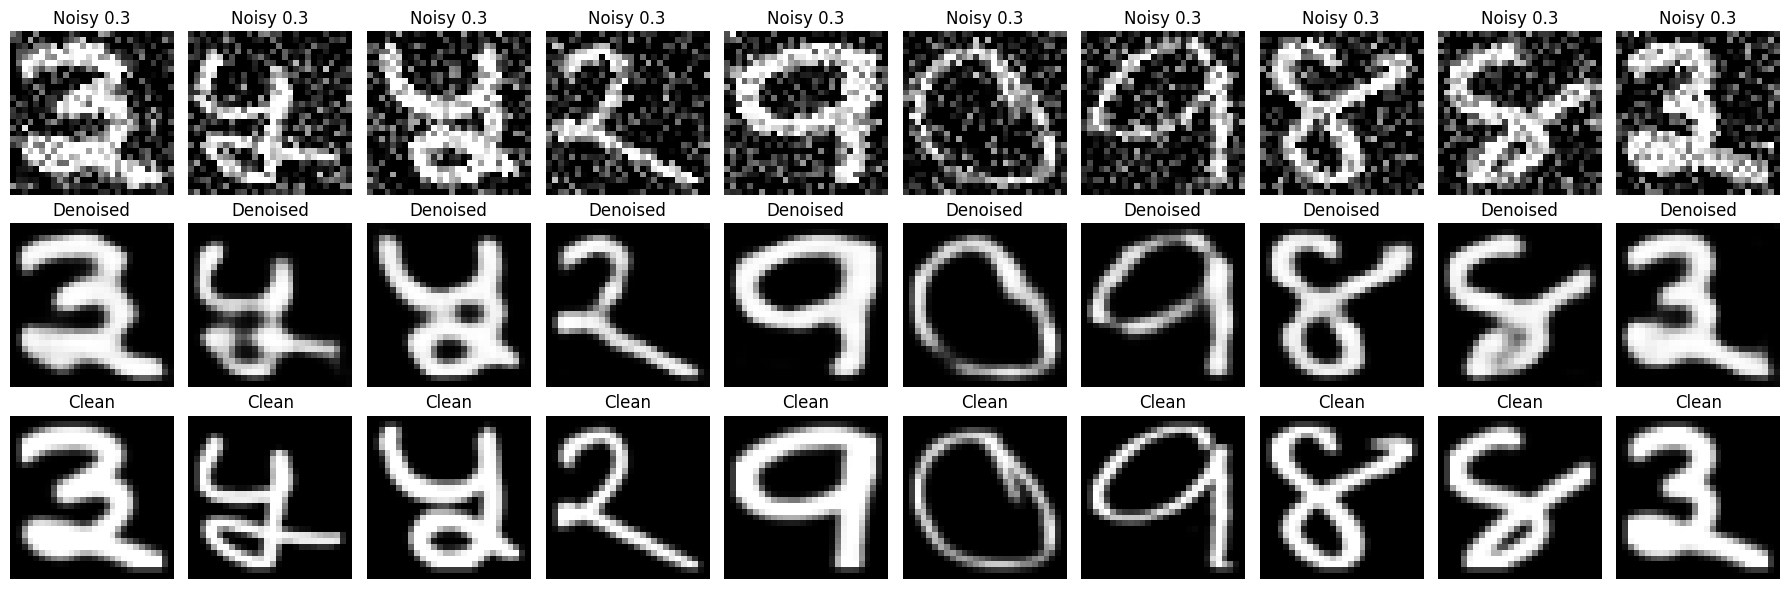

In [17]:
# Task 5C - Show lower-noise results
denoised_03 = autoencoder_03.predict(x_val_noisy_03)

n = 10

plt.figure(figsize=(18, 6))

for i in range(n):
    plt.subplot(3, n, i + 1)
    plt.imshow(x_val_noisy_03[i].reshape(28, 28), cmap="gray")
    plt.title("Noisy 0.3")
    plt.axis("off")

    plt.subplot(3, n, i + 1 + n)
    plt.imshow(denoised_03[i].reshape(28, 28), cmap="gray")
    plt.title("Denoised")
    plt.axis("off")

    plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(x_val[i].reshape(28, 28), cmap="gray")
    plt.title("Clean")
    plt.axis("off")

plt.tight_layout()
plt.show()

## Obeservation

- Noise factor was reduced from 0.5 to 0.3.
- The digits were reconstructed more clearly.
- Validation loss improved from 0.2013 to 0.1705.
- The model worked better with less noisy input images.

## Final conclusion</br>
- The autoencoder reduced noise from the digit images.
- The denoised images were clearer than the noisy images.
- Some outputs were still slightly blurry.
- Training and validation loss both decreased.
- Noise 0.5 gave validation loss 0.2013.
- Noise 0.3 gave better validation loss 0.1705.
- Lower noise gave better reconstruction.